<a href="https://colab.research.google.com/github/hjfuentes/UCH_FCFM/blob/main/DMAvanzado/M01_MatEst/Laboratorio_4_An_lisis_Exploratorio_y_Visualizaci_n_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

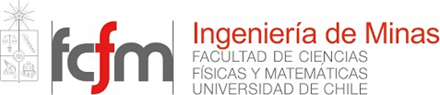

# **Laboratorio 4: Análisis Exploratorio y Visualización de Datos**
*Curso: Matemática y estadística fundamental para el modelamiento en minería y metalurgia*

*Diploma de Apliciones de Modelamiento Avanzado en Minería y Metalurgia*

*Profesores: Xavier Emery, Nadia Mery y Fabián Soto*



# **Highlights de este laboratorio**

En este laboratorio aprenderás:

- explorar distribuciones de variables
- comparar datos según tipo de roca
- identificar relaciones y correlaciones
- analizar patrones espaciales
- y construir visualizaciones interactivas para minería y geociencias.

#Análisis exploratorio de datos (EDA)

El análisis exploratorio de datos (EDA) permite comprender:

- distribuciones
- patrones
- relaciones
- anomalías
- y posibles problemas en los datos.

El objetivo principal es transformar datos en información útil antes de aplicar modelos estadísticos o de machine learning.

| Pregunta EDA | Gráfico sugerido |
|---|---|
| ¿Cómo se distribuye una variable? | Histograma |
| ¿Hay outliers? | Boxplot |
| ¿Cómo cambia una variable por grupo? | Boxplot / violin plot |
| ¿Cuántas muestras hay por categoría? | Barras |
| ¿Hay relación entre dos variables? | Scatter plot |
| ¿Hay correlaciones? | Heatmap |
| ¿Hay patrones espaciales? | Mapas 2D / 3D |

Algunas librería útiles para el EDA se importarán a continuación:

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Para evitar tener que llamar a .show() cada vez que queramos ver un gráfico
%matplotlib inline

`color_palette` define la paleta de colores que utilizará Seaborn en el gráfico.

En este caso, `"Set2"` corresponde a una paleta predefinida de colores suaves y diferenciables.

**Paletas de colores comunes en Seaborn**

| Paleta | Descripción |
|---|---|
| `"Set1"` | Colores intensos y contrastantes. Útil para diferenciar categorías claramente. |
| `"Set2"` | Colores suaves y agradables visualmente. Muy utilizada en gráficos categóricos. |
| `"Pastel1"` | Tonos pastel claros y suaves. Adecuada para gráficos simples y visuales ligeros. |
| `"viridis"` | Gradiente continuo de colores. Muy usada en mapas de calor y variables numéricas. |
| `"coolwarm"` | Gradiente que va de tonos fríos a cálidos. Útil para representar valores bajos y altos. |

In [ ]:
color_palette = "Set2"

##1- Explorando el dataset

Utilizaremos el mismo dataset de sondajes trabajado en el laboratorio anterior, por lo que usaremos nuevamente Google Drive, necesitarás editar estos bloques de código según la ubicación en que tengas guardados tus archivos:

**Recapitulación del preprocesamiento y limpieza de datos**

En el laboratorio anterior trabajamos en la preparación y calidad del dataset de sondajes.

Entre las tareas realizadas se incluyeron:

- inspección inicial del dataset
- identificación de tipos de variables
- detección de valores faltantes
- detección y eliminación de datos de duplicados
- identificación de posibles outliers
- revisión de inconsistencias con correción según corresponda
- transformación de variables categóricas
- y escalamiento/normalización de variables numéricas.

Estas etapas son fundamentales antes de realizar un análisis exploratorio, ya que permiten mejorar la calidad y confiabilidad de los análisis posteriores.

Como resultado se generó un archivo llamado (`dh_df_limpio.csv`)

<font color='red'><b>Importante:</b> El EDA no reemplaza la limpieza de datos: ambas etapas se complementan.</font>

No olvidar lo que significa cada variable

|Nombre|Variable|
|------|--------|
|Easting|Coordenada este|
|Northing|Coordenada norte|
|Elevation|Coordenada elevación|
|Fe|Contenido de Fierro (%)|
|Si|Contenido de Sílice (%)|
|P|Contenido de Fosforo (%)|
|Mn|Contenido de Manganeso (%)|
|Pf|Pérdida de fuego - % en masa perdido por elemento sometido a una T° específica|
|G1|Fracción granulométrica con tamaño particula >6.3 mm (%)|
|Rocktype|Tipo de roca|

In [ ]:
from google.colab import drive # Importar librería de Google Drive

drive.mount('/content/drive') # Montar Google Drive para poder usarlo en este Colab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Indicar qué la ruta del archivo a cargar
#   Modificar la ruta en caso de ser necesario,dependiendo
#   de dónde guardaron el archivo yacimiento_ferrifero

dh_df = pd.read_csv("/content/drive/MyDrive/DIMIN/DIMIN2026/DiploModelamientoDatos/Módulo1/Jupyter/dh_df_limpio.csv", delimiter = ",")

In [ ]:
# Mostrar primeras filas
dh_df.head()

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,...,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
0,-7400.22,1496.58,1457.62,46.478,31.620,0.017,1.139,0.01,0.698,38.16,...,0,0,0,0,0,0,1,0,0,0
1,-7400.22,1496.58,1450.37,40.578,40.838,0.028,0.711,0.01,0.346,78.20,...,0,0,0,0,0,0,1,0,0,0
2,-7400.22,1496.58,1427.72,40.488,40.655,0.012,0.914,0.01,0.482,69.69,...,0,0,0,0,0,1,0,0,0,0
3,-7400.22,1496.58,1421.62,40.488,40.655,0.012,0.914,0.01,0.482,69.69,...,0,0,0,0,0,1,0,0,0,0
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.01,0.432,40.23,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
# Información general del dataset
dh_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Easting    4324 non-null   float64
 1   Northing   4324 non-null   float64
 2   Elevation  4324 non-null   float64
 3   Fe         4324 non-null   float64
 4   Si         4324 non-null   float64
 5   P          4324 non-null   float64
 6   Al         4324 non-null   float64
 7   Mn         4324 non-null   float64
 8   Pf         4324 non-null   float64
 9   g1         4324 non-null   float64
 10  Rocktype   4324 non-null   float64
 11  Ratio      4324 non-null   float64
 12  1.0        4324 non-null   int64  
 13  2.0        4324 non-null   int64  
 14  3.0        4324 non-null   int64  
 15  4.0        4324 non-null   int64  
 16  5.0        4324 non-null   int64  
 17  6.0        4324 non-null   int64  
 18  7.0        4324 non-null   int64  
 19  8.0        4324 non-null   int64  
 20  9.0     

##2- Comprender variables

En un EDA es importante identificar el tipo de variable:

- numéricas
- categóricas
- temporales.

Esto ayuda a seleccionar visualizaciones y análisis adecuados.



In [ ]:
# Mostrar columnas numéricas
dh_df.select_dtypes(include=np.number).columns

Index(['Easting', 'Northing', 'Elevation', 'Fe', 'Si', 'P', 'Al', 'Mn', 'Pf',
       'g1', 'Rocktype', 'Ratio', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0',
       '7.0', '8.0', '9.0', '10.0'],
      dtype='object')

In [ ]:
# Mostrar columnas categóricas
dh_df.select_dtypes(exclude=np.number).columns

Index([], dtype='object')

**Variables numéricas vs categóricas**

No todas las variables almacenadas como números representan cantidades continuas.

Por ejemplo, `Rocktype` aparece como numérica porque utiliza códigos (`1`, `2`, `3`), pero conceptualmente corresponde a una variable categórica.

Esto es importante porque afecta:

- las visualizaciones utilizadas
- los análisis estadísticos
- y la interpretación de resultados.

In [ ]:
# Convertir Rocktype a categórica
dh_df["Rocktype"] = dh_df["Rocktype"].astype("category")

In [ ]:
# Mostrar columnas categóricas
dh_df.select_dtypes(exclude=np.number).columns

Index(['Rocktype'], dtype='object')

**Dummy variables**

Para este análisis exploratorio, las variables dummy no son relevantes, por lo que serán removidas temporalmente del DataFrame.

In [ ]:
dh_df_dummy = dh_df #Crea una copia
dh_df = dh_df.drop(columns=dh_df.columns[12:22]) # Eliminar columnas dummy
dh_df.head()

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype,Ratio
0,-7400.22,1496.58,1457.62,46.478,31.620,0.017,1.139,0.01,0.698,38.16,7.0,1.469892
1,-7400.22,1496.58,1450.37,40.578,40.838,0.028,0.711,0.01,0.346,78.20,7.0,0.993633
2,-7400.22,1496.58,1427.72,40.488,40.655,0.012,0.914,0.01,0.482,69.69,6.0,0.995892
3,-7400.22,1496.58,1421.62,40.488,40.655,0.012,0.914,0.01,0.482,69.69,6.0,0.995892
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.01,0.432,40.23,7.0,1.229008


##3- Estadísticas descriptivas

Las estadísticas descriptivas permiten resumir el comportamiento general de las variables.

In [ ]:
# Estadísticas descriptivas
dh_df.describe()

#Si me interesa solo de una variable puedo agregar el nombre de la variable entre paréntesis usando comillas
#dh_df[["Fe", "Si"]].describe()

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Ratio
count,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000
mean,-6402.255083,1392.107662,1322.709181,52.181933,21.252394,0.054371,1.290702,0.266711,2.231759,33.542139,18.074511
std,530.934899,186.294911,85.557852,11.014075,16.809574,0.040948,1.288048,1.329866,2.018141,23.399715,34.852201
min,-7501.240000,902.280000,1025.580000,24.316000,0.217000,0.007000,0.100000,0.008000,0.057000,0.302000,0.376642
25%,-6799.920000,1265.892500,1277.877500,42.939750,4.241250,0.027000,0.448750,0.013000,0.811000,15.258000,1.208152
50%,-6350.090000,1386.835000,1336.515000,53.151500,19.758000,0.044000,0.893500,0.029000,1.569000,27.336000,2.677953
75%,-6000.000000,1506.710000,1379.350000,62.337750,35.766250,0.070000,1.670250,0.081000,2.874750,47.835500,14.781788
max,-5386.290000,1937.520000,1517.900000,69.529000,64.560000,0.530000,12.599000,32.057000,13.835000,98.184000,317.903226


##4- Distribución de variables numéricas



###4.1. Histogramas

Los histogramas permiten visualizar:

- dispersión
- asimetría
- multimodalidad
- y posibles anomalías.

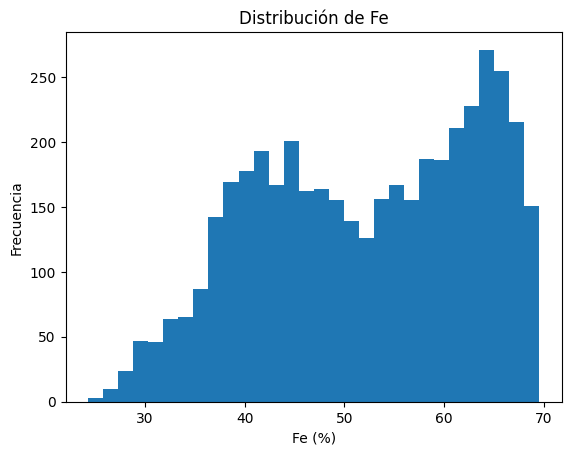

In [ ]:
# Histograma de Fe

plt.hist(dh_df["Fe"], bins=30)  # Crear histograma de la variable Fe utilizando 30 intervalos (bins)
plt.xlabel("Fe (%)")  # Etiqueta del eje X
plt.ylabel("Frecuencia")  # Etiqueta del eje Y
plt.title("Distribución de Fe")  # Título del gráfico
plt.show()  # Mostrar el gráfico

**Preguntas de interpretación**

- ¿La distribución es simétrica o asimétrica?
- ¿Existen valores extremos?
- ¿Hay concentración de valores en algún rango?
- ¿La distribución parece unimodal o multimodal?

### 4.2. Boxplots

Los boxplots permiten identificar:

- medianas
- dispersión
- y posibles outliers.

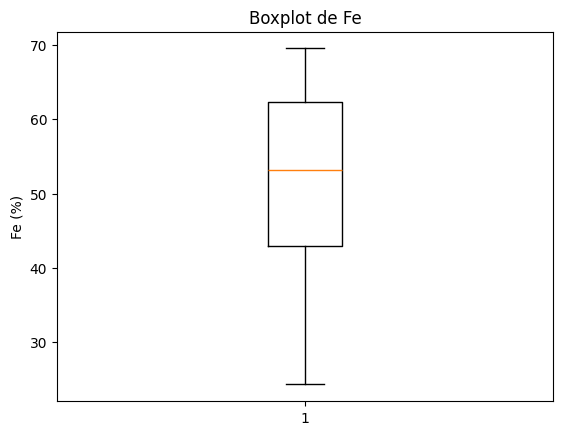

In [ ]:
# Boxplot de la variable Fe
plt.boxplot(dh_df["Fe"])  # Crear boxplot para visualizar distribución y posibles outliers
plt.ylabel("Fe (%)")  # Etiqueta del eje Y
plt.title("Boxplot de Fe")  # Título del gráfico
plt.show()  # Mostrar el gráfico

**Preguntas de interpretación**

- ¿Existen outliers?
- ¿Cuál es la dispersión de los datos?
- ¿La mediana está centrada?
- ¿Existen posibles asimetrías?

### 4.3. Violin plot

Los violin plots permiten visualizar la distribución de los datos y su densidad de probabilidad.

Combinan características de:

- Boxplots → mediana, cuartiles y dispersión
- Histogramas/densidad → forma de la distribución

Son útiles para identificar:

- concentración de datos
- asimetrías
- multimodalidad
- posibles outliers.

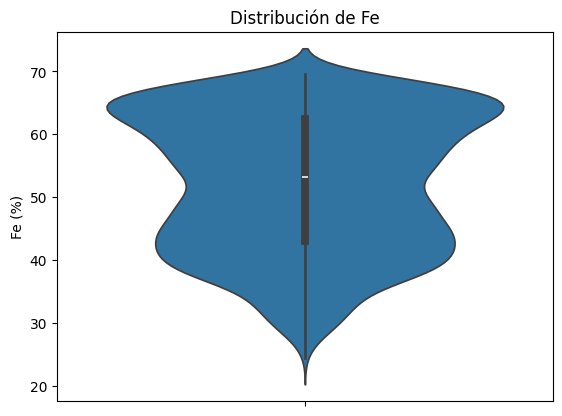

In [ ]:
# Violin plot de la variable FE
sns.violinplot(y=dh_df["Fe"])  # Crear violin plot para visualizar la distribución y densidad de Fe
plt.title("Distribución de Fe")  # Título del gráfico
plt.ylabel("Fe (%)") # Etiqueta del eje Y
plt.show()  # Mostrar el gráfico

**Preguntas de interpretación**

- ¿Qué nos dice el violin plot?


> ## 🛠️ Mini desafío 1
>
> Repetir el análisis para:
>
> - `Si`
>
> e interpretar:
>
> - distribución
> - dispersión
> - y posibles outliers.

##5- Análisis de variables categóricas

### 5.1. Cantidad de datos por variable categórica



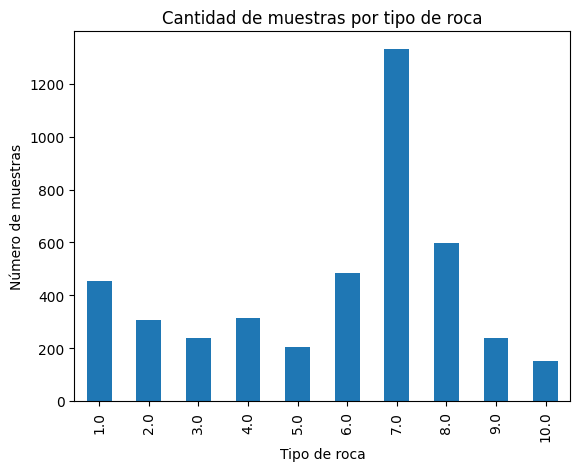

In [ ]:
#Gráfico de la cantidad de datos según tipo de roca
dh_df["Rocktype"].value_counts().sort_index().plot(kind="bar") # Contar muestras por tipo de roca, ordenar por categoría y crear gráfico de barras
plt.xlabel("Tipo de roca") # Etiqueta del eje X
plt.ylabel("Número de muestras") # Etiqueta del eje Y
plt.title("Cantidad de muestras por tipo de roca") # Título del gráfico
plt.show() # Mostrar el gráfico

### 5.2. `groupby()`

Permite separar las filas según una categoría y calcular estadísticas para cada grupo.

In [ ]:
# Media de Fe por tipo de roca
# Para graficar con más claridad, resumimos los datos agrupando por Rocktype
# mean() promedia los valores numéricos de cada variable por Rocktype
# si se necesita se puede sumar usando sum() para acumular los valores numéricos de cada variable por Rocktype

dh_g = dh_df.groupby("Rocktype")["Fe"].mean()
dh_g

/tmp/ipykernel_14929/568113756.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Fe
Rocktype,
1.0,64.773754
2.0,66.121795
3.0,63.798862
4.0,51.609508
5.0,49.044127
6.0,42.642200
7.0,42.924078
8.0,57.003012
9.0,55.406510


In [ ]:
dh_df.groupby("Rocktype", observed=True)["Fe"].mean()

,Fe
Rocktype,
1.0,64.773754
2.0,66.121795
3.0,63.798862
4.0,51.609508
5.0,49.044127
6.0,42.642200
7.0,42.924078
8.0,57.003012
9.0,55.406510


In [ ]:
# Estadísticas de Fe por tipo de roca

dh_df.groupby("Rocktype", observed=True)["Fe"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
Rocktype,,,,
1.0,64.773754,3.269003,37.128,69.349
2.0,66.121795,4.177578,40.025,69.529
3.0,63.798862,2.001066,51.096,68.777
4.0,51.609508,8.302910,29.672,66.288
5.0,49.044127,8.272934,26.922,66.534
6.0,42.642200,8.759242,25.557,68.321
7.0,42.924078,6.945665,24.316,69.305
8.0,57.003012,4.330880,41.797,68.318
9.0,55.406510,6.465877,29.072,65.199


### 5.3 Box plot por variable categórica



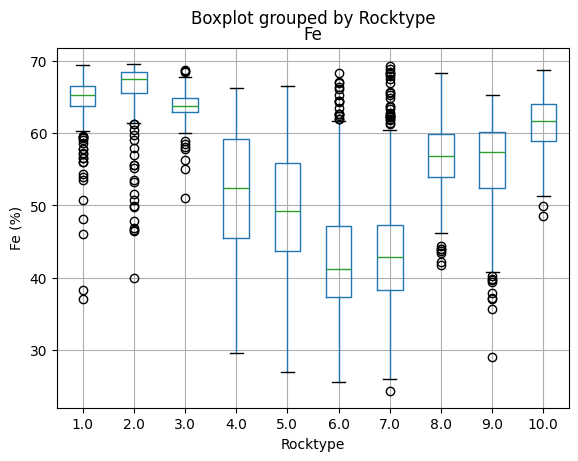

In [ ]:
# Boxplot de Fe por tipo de roca

dh_df.boxplot(column="Fe",by="Rocktype")
plt.ylabel("Fe (%)")
plt.show()

### 5.4. Violin plot por variable categórica


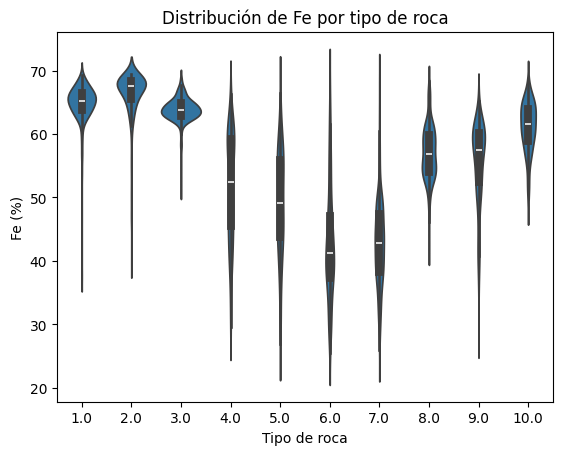

In [ ]:
sns.violinplot(data=dh_df,x="Rocktype",y="Fe")

plt.title("Distribución de Fe por tipo de roca")
plt.xlabel("Tipo de roca")
plt.ylabel("Fe (%)")
plt.show()

### 5.5. Histograma por variable categórica

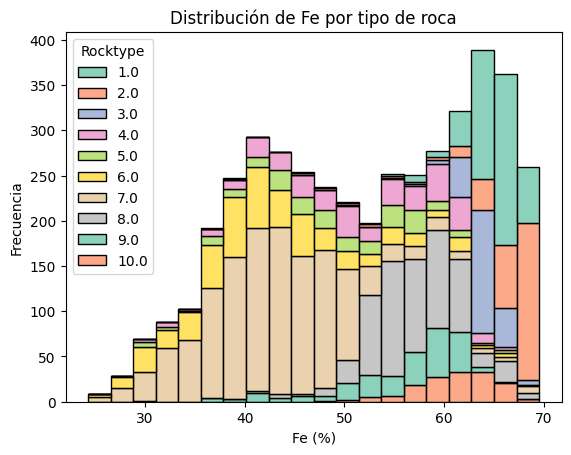

In [ ]:
# Histograma apilado por tipo de roca
sns.histplot(data=dh_df,x='Fe',hue='Rocktype',bins=20,multiple='stack',palette=color_palette) #multiple ='stack' permite apilar las barras de cada categoría

# Etiquetas y título
plt.xlabel("Fe (%)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Fe por tipo de roca")
plt.show() # Mostrar gráfico

 ### 5.6. `.pivot`

Se usa para reorganizar un DataFrame cambiando la disposición de sus datos: convierte valores de una columna en nuevas columnas, usando otra columna como índice.



pandas-dataframe-pivot-1.svg


Veámoslo ejemplificado con el dataframe del yacimiento ferrífero

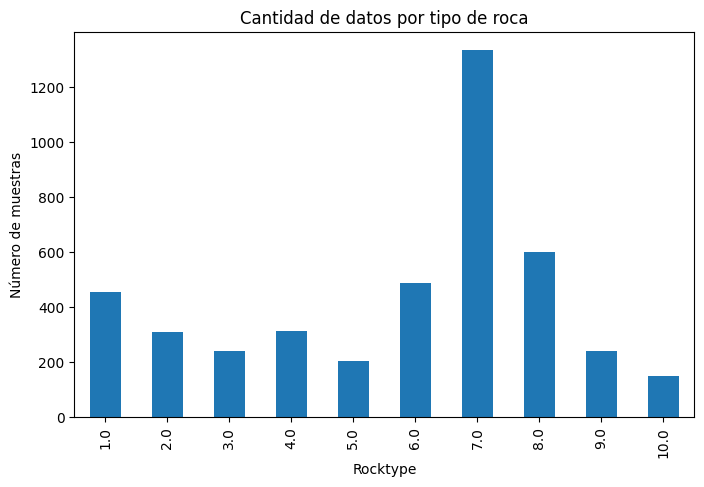

In [ ]:
rock_counts = pd.pivot_table(dh_df,index="Rocktype", values="Fe", aggfunc="count",observed=True)
rock_counts.columns = ["Cantidad"]
rock_counts

rock_counts["Cantidad"].plot(kind="bar",figsize=(8,5))

plt.title("Cantidad de datos por tipo de roca")
plt.xlabel("Rocktype")
plt.ylabel("Número de muestras")
plt.show()

**Notar que** esta figura es la misma que obtuvimos al inicio del estudio de variables categóricas.

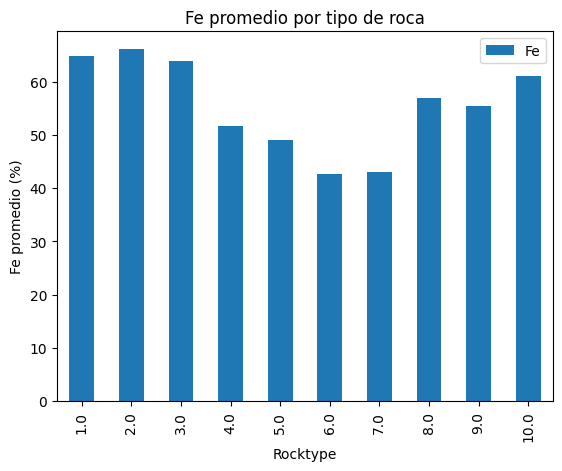

In [ ]:
pivot_fe = pd.pivot_table(dh_df,values="Fe",index="Rocktype",aggfunc="mean",observed=True)
pivot_fe.plot(kind="bar")
plt.ylabel("Fe promedio (%)")
plt.title("Fe promedio por tipo de roca")
plt.show()

##6- Relaciones entre variables


### 6.1. Scatter plot

Los scatterplots permiten explorar relaciones entre variables numéricas.

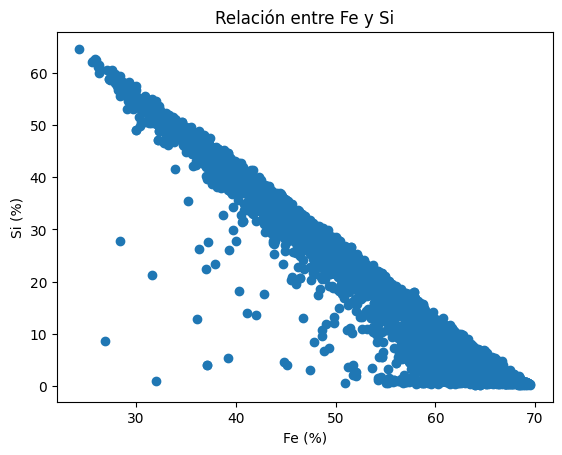

In [ ]:
# Scatterplot Fe vs Si

plt.scatter(dh_df["Fe"],dh_df["Si"])

plt.xlabel("Fe (%)")
plt.ylabel("Si (%)")
plt.title("Relación entre Fe y Si")
plt.show()

**Preguntas de interpretación**

- ¿Existe relación entre ambas variables?
- ¿La relación parece positiva o negativa?
- ¿Existen outliers o valores anómalos?

Los scatter plots igual se pueden realizar considerando alguna variable categórica

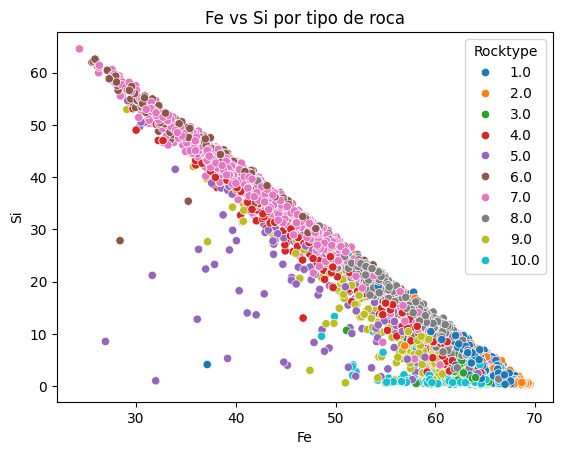

In [ ]:
sns.scatterplot(data=dh_df,x="Fe", y="Si",hue="Rocktype")

plt.title("Fe vs Si por tipo de roca")
plt.show()

> ## 🛠️ Mini desafío 2
>
> Construir un scatterplot utilizando:
>
> - `P` y `Mn`
>
> e interpretar la relación observada.

### 6.2. Matrices de correlación

Las matrices de correlación permiten identificar relaciones lineales entre variables.

In [ ]:
# Matriz de correlación
corr = dh_df.corr(numeric_only=True)
corr

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Ratio
Easting,1.000000,-0.278109,0.127693,0.036424,-0.063436,0.114450,-0.039795,0.057330,0.211372,-0.016509,0.012264
Northing,-0.278109,1.000000,0.072845,0.063793,-0.059886,0.130464,-0.003798,-0.204706,0.176647,0.035004,0.053658
Elevation,0.127693,0.072845,1.000000,0.437496,-0.496877,0.142262,0.379468,0.054978,0.390194,-0.200699,0.191164
Fe,0.036424,0.063793,0.437496,1.000000,-0.972237,0.150063,0.217544,-0.082289,0.204452,0.088132,0.570511
Si,-0.063436,-0.059886,-0.496877,-0.972237,1.000000,-0.283209,-0.387043,-0.062458,-0.391128,-0.063849,-0.566734
P,0.114450,0.130464,0.142262,0.150063,-0.283209,1.000000,0.421260,0.142947,0.710194,0.033378,0.105295
Al,-0.039795,-0.003798,0.379468,0.217544,-0.387043,0.421260,1.000000,0.139001,0.683867,-0.168249,0.161239
Mn,0.057330,-0.204706,0.054978,-0.082289,-0.062458,0.142947,0.139001,1.000000,0.166054,-0.042630,-0.039771
Pf,0.211372,0.176647,0.390194,0.204452,-0.391128,0.710194,0.683867,0.166054,1.000000,-0.004862,0.191074
g1,-0.016509,0.035004,-0.200699,0.088132,-0.063849,0.033378,-0.168249,-0.042630,-0.004862,1.000000,0.346022


<Axes: >

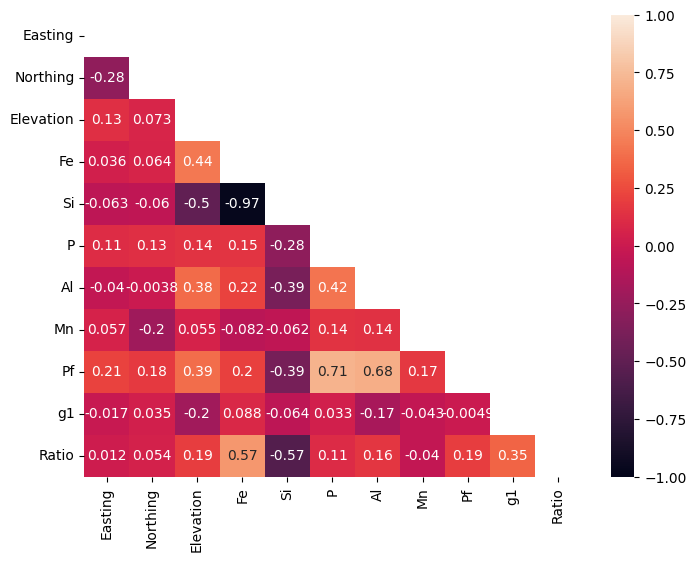

In [ ]:
# Heatmap de correlaciones

# Ocultar la mitad superior del heatmap (redundante)
matrix = np.triu(corr)

# Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(corr,
            annot=True, # Mostrar el valor numérico en cada celda
            mask=matrix, # Ocultar la mitad superior
            vmin=-1,         # Valor mínimo de la escala
            vmax=1 )          # Valor máximo de la escala)

**Preguntas de interpretación**

- ¿Qué variables presentan mayor correlación?
- ¿Existen correlaciones negativas?
- ¿Qué variables presentan nulas correlaciones?

### 6.3. Pair plot

Un pair plot permite visualizar relaciones entre múltiples variables numéricas al mismo tiempo.

Muestra:

- dispersión entre pares de variables
- distribuciones individuales
- correlaciones
- patrones y agrupamientos
- posibles outliers


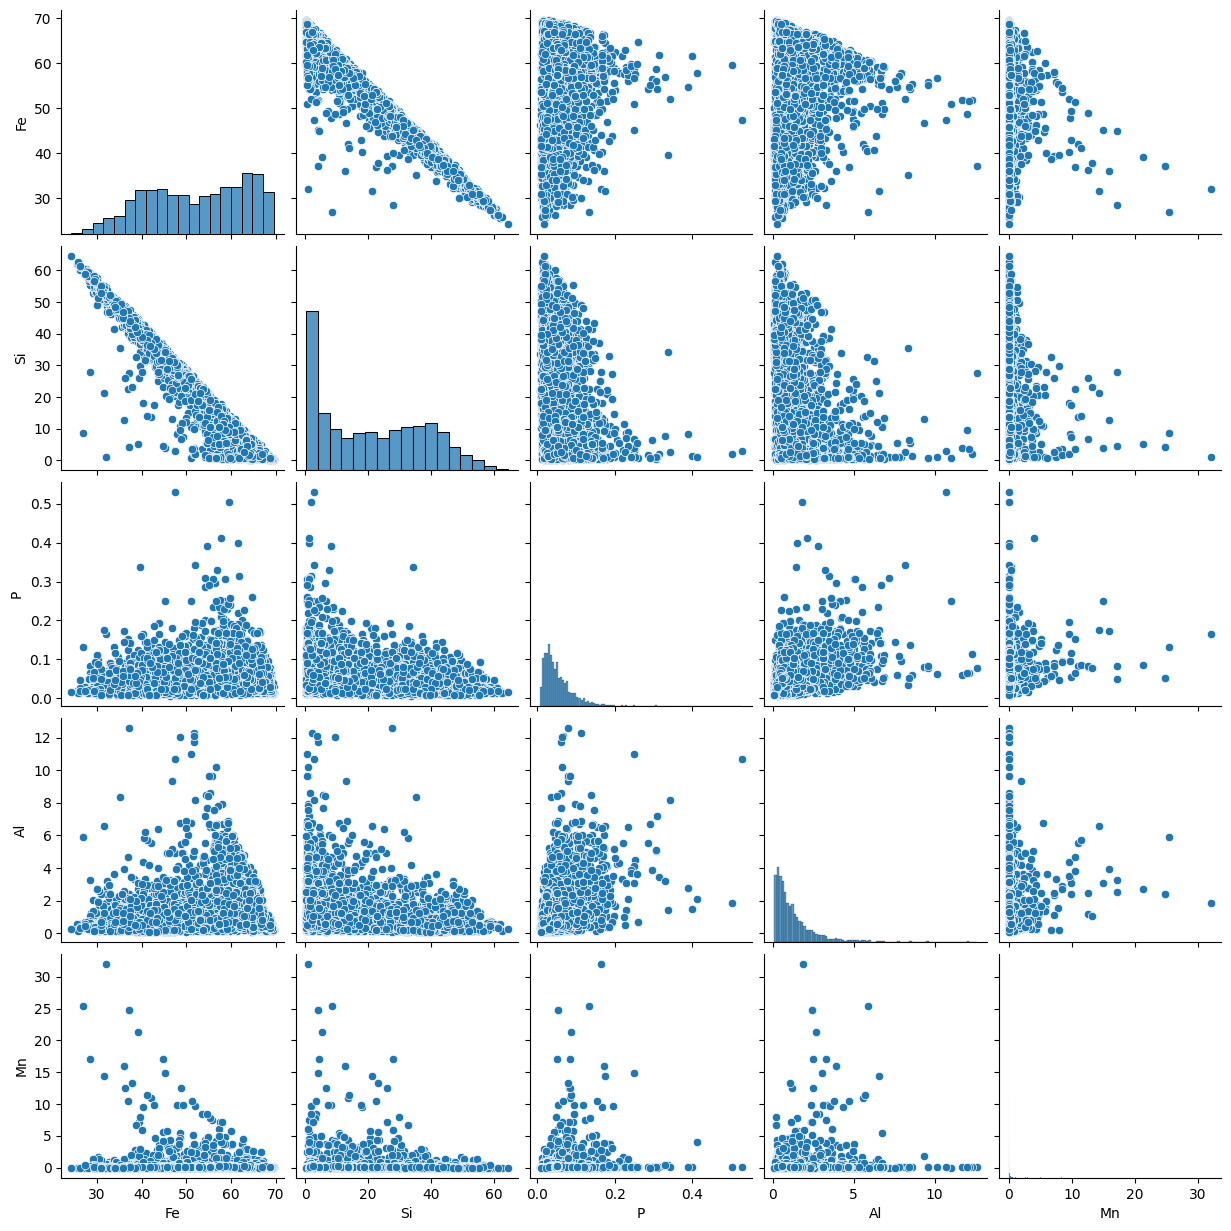

In [ ]:
sns.pairplot(
    dh_df[["Fe", "Si", "P", "Al", "Mn", "Rocktype"]])

**Preguntas de interpretación**

- ¿Qué variables parecen más correlacionadas?
- ¿Existen agrupamientos por tipo de roca?
- ¿Se observan relaciones lineales o no lineales?

Es posible visualizar el pairplot considerando variables categóricas. Quitar el símbolo # al siguiente código para verlo

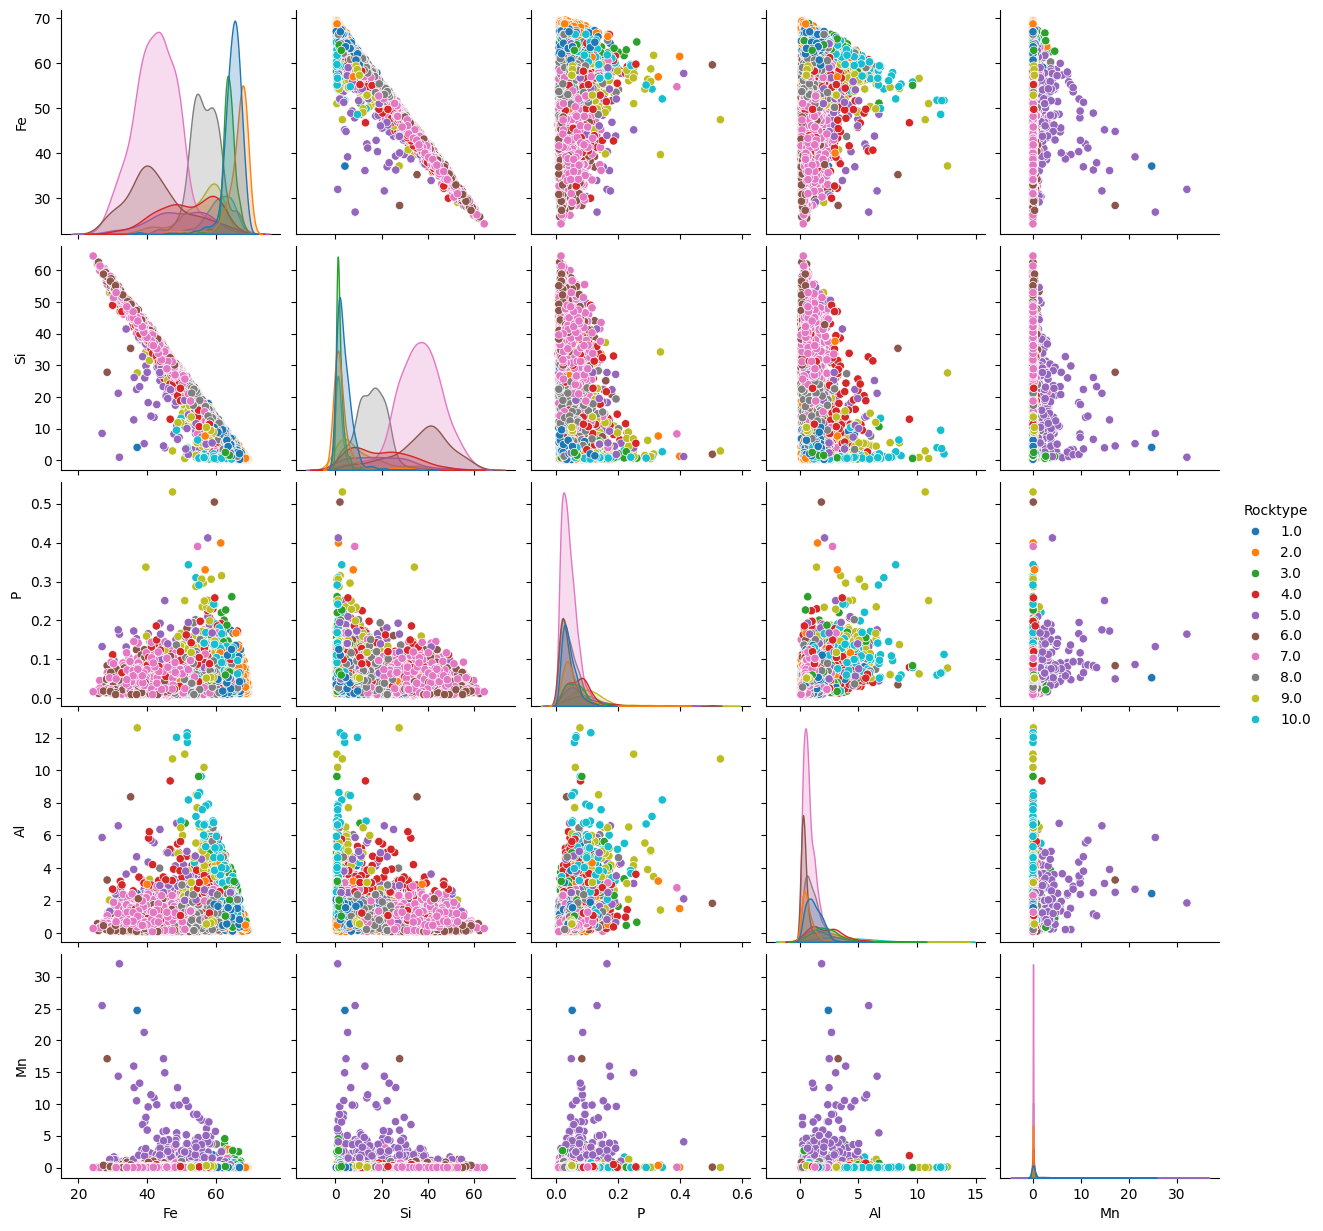

In [ ]:
sns.pairplot(dh_df[["Fe", "Si", "P", "Al", "Mn", "Rocktype"]],hue="Rocktype")

##7- Análisis espaciales

### 7.1 Tendencia de leyes según elevación

Los gráficos de línea pueden utilizarse para explorar tendencias espaciales o verticales en los datos.

In [ ]:
s = pd.cut(dh_df["Elevation"],bins=20)

In [ ]:
s

,Elevation
0,"(1444.052, 1468.668]"
1,"(1444.052, 1468.668]"
2,"(1419.436, 1444.052]"
3,"(1419.436, 1444.052]"
4,"(1394.82, 1419.436]"
...,...
4319,"(1394.82, 1419.436]"
4320,"(1394.82, 1419.436]"
4321,"(1394.82, 1419.436]"
4322,"(1370.204, 1394.82]"


In [ ]:
s.loc[0]

Interval(1444.052, 1468.668, closed='right')

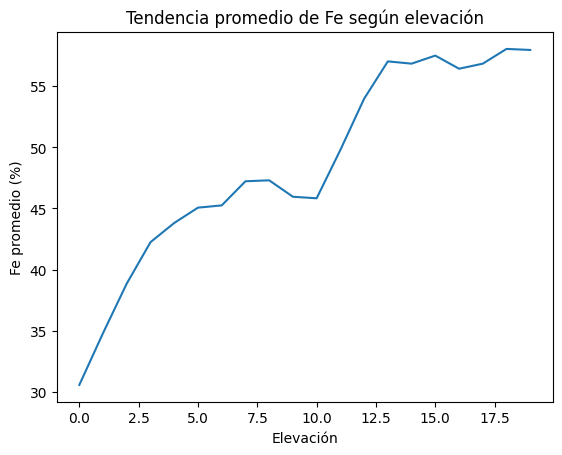

In [ ]:
dh_df["Elevation_bin"] = pd.cut(dh_df["Elevation"],bins=20) # Crear intervalos de elevación

fe_by_elevation = dh_df.groupby("Elevation_bin",observed=True)["Fe"].mean() # Calcular promedio de Fe por intervalo

plt.plot(range(len(fe_by_elevation)),fe_by_elevation.values) # Graficar tendencia promedio


plt.xlabel("Elevación")
plt.ylabel("Fe promedio (%)")
plt.title("Tendencia promedio de Fe según elevación")
plt.show()

### 7.2. Vistas 2D espaciales del dataset

Como el dataset contiene coordenadas espaciales, podemos explorar la distribución de Fe desde distintas vistas:

- vista en planta: `Easting` vs `Northing`;
- vista en sección: `Easting` vs `Elevation`;
- vista en sección:  `Northing` vs `Elevation`.

Esto permite identificar patrones espaciales, zonas con mayor concentración y posibles tendencias en direcciones.

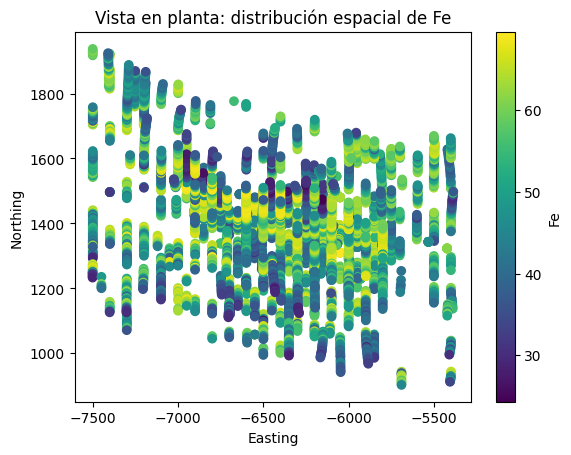

In [ ]:
# Vista planta: Easting vs Northing

plt.scatter(
    dh_df["Easting"],
    dh_df["Northing"],
    c=dh_df["Fe"]
)

plt.colorbar(label="Fe")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Vista en planta: distribución espacial de Fe")
plt.show()

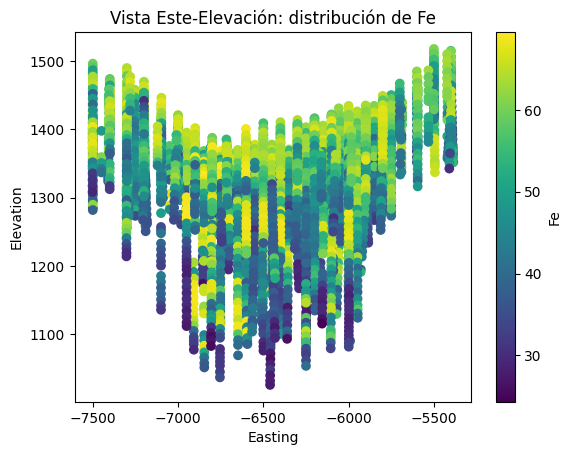

In [ ]:
# Vista Este-Elevación: Easting vs Elevation

plt.scatter(
    dh_df["Easting"],
    dh_df["Elevation"],
    c=dh_df["Fe"]
)

plt.colorbar(label="Fe")
plt.xlabel("Easting")
plt.ylabel("Elevation")
plt.title("Vista Este-Elevación: distribución de Fe")
plt.show()

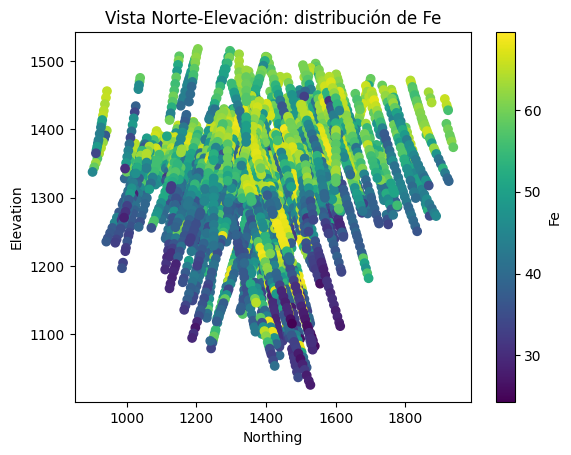

In [ ]:
# Vista Norte-Elevación: Northing vs Elevation

plt.scatter(
    dh_df["Northing"],
    dh_df["Elevation"],
    c=dh_df["Fe"]
)

plt.colorbar(label="Fe")
plt.xlabel("Northing")
plt.ylabel("Elevation")
plt.title("Vista Norte-Elevación: distribución de Fe")
plt.show()

**Distribución espacial por tipo de roca**

Además de visualizar leyes, también es posible explorar la distribución espacial de los distintos tipos de roca.

Esto permite identificar:

- dominios geológicos
- agrupamientos espaciales
- contactos entre unidades
- y patrones de distribución.

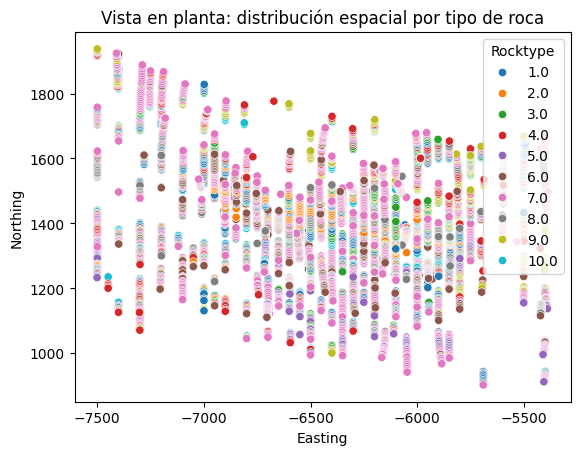

In [ ]:
# Vista planta: Easting vs Northing

sns.scatterplot(
    data=dh_df,
    x="Easting",
    y="Northing",
    hue="Rocktype"
)

plt.title("Vista en planta: distribución espacial por tipo de roca")

plt.show()

El siguiente gráfico interactivo permite visualizar espacialmente las muestras utilizando sus coordenadas (`Easting` y `Northing`).

Además:

- El color representa la concentración de Fe.
- La animación permite recorrer los distintos tipos de roca (`Rocktype`).
- Es posible hacer zoom, desplazarse e inspeccionar puntos individualmente.

Este tipo de visualización es útil para explorar patrones espaciales y variaciones geológicas en los datos.

In [ ]:
import plotly.express as px # Importar Plotly Express para crear gráficos interactivos de forma simple

In [ ]:
fig = px.scatter(
    dh_df,                    # DataFrame que contiene los datos
    x="Easting",              # Variable para el eje X
    y="Northing",             # Variable para el eje Y
    color="Fe",               # Color de cada punto según concentración de Fe
    animation_frame="Rocktype" # Crear animación según tipo de roca
)

fig.show()  # Mostrar gráfico interactivo

**Preguntas de interpretación**

- ¿Existen zonas con mayores leyes?
- ¿Se observan agrupamientos espaciales?
- ¿Los tipos de roca presentan distribución espacial diferenciada?

### 7.3. Visualización espacial 3D

Los datasets de sondajes contienen información espacial tridimensional.

Esto permite explorar patrones geológicos en el espacio.

In [ ]:
import plotly.express as px # Importar Plotly Express para crear gráficos interactivos de forma simple

In [ ]:
fig = px.scatter_3d(
    dh_df,
    x="Easting",
    y="Northing",
    z="Elevation",
    color="Fe"
)

fig.show()

> ## 🛠️ Mini desafío 3
>
> Repetir el análisis espacial para la variable
>
 - `Si`
>


# <font color='green'>**Complemento: Visualización interactiva**</font>

**Scatter plot**

In [ ]:
# <font color='green'>**Complemento: Scatter interactivo con botones**</font>

import plotly.graph_objects as go

# Variables disponibles
variables = ["Fe", "Si", "P", "Al", "Mn"]

# Variables iniciales
x_inicial = "Fe"
y_inicial = "Fe"

# Crear figura
fig = go.Figure()

# Crear una traza por tipo de roca
for rock in sorted(dh_df["Rocktype"].unique()):

    temp = dh_df[
        dh_df["Rocktype"] == rock
    ]

    fig.add_trace(
        go.Scatter(
            x=temp[x_inicial],
            y=temp[y_inicial],
            mode="markers",
            name=f"Rocktype {rock}",
            text=temp["Rocktype"],
            hovertemplate=(
                "X: %{x}<br>"
                "Y: %{y}<br>"
                "Rocktype: %{text}<extra></extra>"
            )
        )
    )

# Botones eje X
botones_x = []

for var in variables:

    botones_x.append(
        dict(
            label=f"X: {var}",
            method="update",
            args=[
                {
                    "x": [
                        dh_df[dh_df["Rocktype"] == rock][var]
                        for rock in sorted(dh_df["Rocktype"].unique())
                    ]
                },
                {
                    "xaxis": {"title": var}
                }
            ]
        )
    )

# Botones eje Y
botones_y = []

for var in variables:

    botones_y.append(
        dict(
            label=f"Y: {var}",
            method="update",
            args=[
                {
                    "y": [
                        dh_df[dh_df["Rocktype"] == rock][var]
                        for rock in sorted(dh_df["Rocktype"].unique())
                    ]
                },
                {
                    "yaxis": {"title": var}
                }
            ]
        )
    )

# Layout
fig.update_layout(
    title="Scatter interactivo con selección de variables",
    xaxis_title=x_inicial,
    yaxis_title=y_inicial,

    updatemenus=[

        dict(
            buttons=botones_x,
            direction="down",
            x=0.00,
            y=1.1,
            showactive=True
        ),

        dict(
            buttons=botones_y,
            direction="down",
            x=0.20,
            y=1.1,
            showactive=True
        )
    ]
)

fig.show()

**Histograma**

In [ ]:
# <font color='green'>**Complemento: Histograma interactivo con botones**</font>

import plotly.graph_objects as go

# Variables disponibles para graficar
variables = ["Fe", "Si", "P", "Al", "Mn"]

# Variable inicial
var_inicial = "Fe"

# Crear figura inicial
fig = go.Figure()

# Crear una traza por tipo de roca
for rock in sorted(dh_df["Rocktype"].unique()):

    temp = dh_df[
        dh_df["Rocktype"] == rock
    ]

    fig.add_trace(
        go.Histogram(
            x=temp[var_inicial],
            name=f"Rocktype {rock}",
            opacity=0.75
        )
    )

# Botones para cambiar variable
botones = []

for var in variables:

    botones.append(
        dict(
            label=var,
            method="update",
            args=[
                {
                    "x": [
                        dh_df[dh_df["Rocktype"] == rock][var]
                        for rock in sorted(dh_df["Rocktype"].unique())
                    ]
                },
                {
                    "title": f"Histograma interactivo de {var}",
                    "xaxis": {"title": var}
                }
            ]
        )
    )

# Layout
fig.update_layout(
    title=f"Histograma interactivo de {var_inicial}",
    xaxis_title=var_inicial,
    yaxis_title="Frecuencia",
    barmode="overlay",
    updatemenus=[
        dict(
            buttons=botones,
            direction="down",
            x=0.0,
            y=1.15,
            showactive=True
        )
    ]
)

fig.show()

**Vistas espaciales**

In [ ]:
# <font color='green'>**Complemento: Vistas espaciales interactivas**</font>

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Variables disponibles para colorear
variables = ["Fe", "Si", "P", "Al", "Mn"]

# Variable inicial
var_inicial = "Fe"

# Crear subplots
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        "Vista XY: Easting vs Northing",
        "Vista XZ: Easting vs Elevation",
        "Vista YZ: Northing vs Elevation"
    ]
)

# Vista XY
fig.add_trace(
    go.Scatter(
        x=dh_df["Easting"],
        y=dh_df["Northing"],
        mode="markers",
        marker=dict(
            color=dh_df[var_inicial],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(title=var_inicial)
        ),
        text=dh_df["Rocktype"],
        hovertemplate=(
            "Easting: %{x}<br>"
            "Northing: %{y}<br>"
            "Rocktype: %{text}<extra></extra>"
        ),
        name="XY"
    ),
    row=1,
    col=1
)

# Vista XZ
fig.add_trace(
    go.Scatter(
        x=dh_df["Easting"],
        y=dh_df["Elevation"],
        mode="markers",
        marker=dict(
            color=dh_df[var_inicial],
            colorscale="Viridis",
            showscale=False
        ),
        text=dh_df["Rocktype"],
        hovertemplate=(
            "Easting: %{x}<br>"
            "Elevation: %{y}<br>"
            "Rocktype: %{text}<extra></extra>"
        ),
        name="XZ"
    ),
    row=1,
    col=2
)

# Vista YZ
fig.add_trace(
    go.Scatter(
        x=dh_df["Northing"],
        y=dh_df["Elevation"],
        mode="markers",
        marker=dict(
            color=dh_df[var_inicial],
            colorscale="Viridis",
            showscale=False
        ),
        text=dh_df["Rocktype"],
        hovertemplate=(
            "Northing: %{x}<br>"
            "Elevation: %{y}<br>"
            "Rocktype: %{text}<extra></extra>"
        ),
        name="YZ"
    ),
    row=1,
    col=3
)

# Botones para cambiar variable de color
botones = []

for var in variables:

    botones.append(
        dict(
            label=var,
            method="update",
            args=[
                {
                    "marker.color": [
                        dh_df[var],
                        dh_df[var],
                        dh_df[var]
                    ]
                },
                {
                    "title": f"Vistas espaciales coloreadas por {var}"
                }
            ]
        )
    )

# Layout
fig.update_layout(
    title=f"Vistas espaciales coloreadas por {var_inicial}",
    height=500,
    width=1300,
    updatemenus=[
        dict(
            buttons=botones,
            direction="down",
            x=0.0,
            y=1.18,
            showactive=True
        )
    ]
)

# Etiquetas de ejes
fig.update_xaxes(title_text="Easting", row=1, col=1)
fig.update_yaxes(title_text="Northing", row=1, col=1)

fig.update_xaxes(title_text="Easting", row=1, col=2)
fig.update_yaxes(title_text="Elevation", row=1, col=2)

fig.update_xaxes(title_text="Northing", row=1, col=3)
fig.update_yaxes(title_text="Elevation", row=1, col=3)

fig.show()